<a href="https://colab.research.google.com/github/SANGRAMLEMBE/100_days_of_ML/blob/main/Day36_Handling_Missing_Data/Handling_Missing_Data_Numerical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


In [5]:
df  = pd.read_csv("titanic_toy.csv")
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [7]:
df.isnull().mean()  # percentage of missing data

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [8]:
x = df.drop(columns = ['Survived'])

In [9]:
y = df['Survived']

In [10]:
x_train , x_test, y_train , y_test = train_test_split(x,y,test_size=0.2, random_state = 2)


In [11]:
x_train.shape, x_test.shape

((712, 3), (179, 3))

In [12]:
x_train.isnull().mean()

,0
Age,0.207865
Fare,0.050562
Family,0.000000


In [13]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()
mode_age = x_train['Age'].mode()

mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()
mode_fare = x_train['Fare'].mode()

In [16]:
x_train['Age_median'] = x_train['Age'].fillna(median_age)
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)

x_train['Fare_median'] = x_train['Fare'].fillna(median_fare)
x_train['Fare_mean'] = x_train['Fare'].fillna(mean_fare)

In [17]:
x_train.sample(10)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
824,2.0,39.6875,5,2.00,2.000000,39.6875,39.6875
77,NaN,8.0500,0,28.75,29.785904,8.0500,8.0500
178,30.0,13.0000,0,30.00,30.000000,13.0000,13.0000
578,NaN,14.4583,1,28.75,29.785904,14.4583,14.4583
775,18.0,7.7500,0,18.00,18.000000,7.7500,7.7500
45,NaN,8.0500,0,28.75,29.785904,8.0500,8.0500
823,27.0,12.4750,1,27.00,27.000000,12.4750,12.4750
642,2.0,27.9000,5,2.00,2.000000,27.9000,27.9000
175,18.0,7.8542,2,18.00,18.000000,7.8542,7.8542
705,39.0,26.0000,0,39.00,39.000000,26.0000,26.0000


In [20]:
print('Original Age variable variance:', x_train['Age'].var())
print('Age imputed with median variance:', x_train['Age_median'].var())
print('Age imputed with mean variance:', x_train['Age_mean'].var())

print('Original fare variable varience', x_train['Fare'].var())
print('Fare imputed with median variance:', x_train['Fare_median'].var())
print('Fare imputed with mean variance:', x_train['Fare_mean'].var())

Original Age variable variance: 204.3495133904614
Age imputed with median variance: 161.9895663346054
Age imputed with mean variance: 161.81262452718673
Original fare variable varience 2448.197913706318
Fare imputed with median variance: 2340.0910219753637
Fare imputed with mean variance: 2324.2385256705547


<Axes: ylabel='Density'>

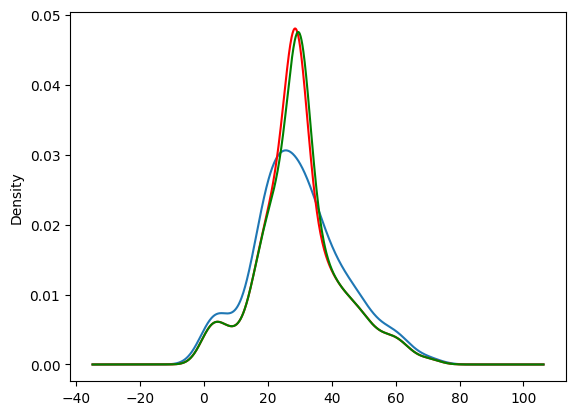

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind = 'kde', ax = ax)
x_train['Age_median'].plot(kind = 'kde', ax = ax, color = 'red')
x_train['Age_mean'].plot(kind = 'kde', ax = ax, color = 'green')